# 05-02 · CDF Uncertainty Analysis — Historical vs. Future

Loads all 12 Pareto member pickles produced by `05_01`, applies event filtering,
and produces the main climate change figure:

- **Panel (a)** — Peak discharge ECDF on a logit scale, with Pareto parameter
  uncertainty shown as shaded bands around the ensemble envelope.
- **Panel (b)** — Total runoff volume ECDF, same structure.

The band width represents **parameter equifinality** (12 Pareto members);
the separation between Historical and Future bands represents the
**climate change signal**.  A Wilcoxon signed-rank test on paired samples
(same event, same shift) from the optimum member gives the statistical
significance of the shift.


In [1]:
from pathlib import Path
import numpy as np

# ── Paths ──────────────────────────────────────────────────────────────────────
RAW_DIR = Path(r"D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\climate\raw")
FIG_DIR = Path(r"D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\climate\figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Ensemble ───────────────────────────────────────────────────────────────────
PARETO_INDICES = [682, 701, 708, 709, 710, 717, 718, 719, 727, 728, 898, 917]
OPTIMUM_IDX    = 708

# ── Urbanization scenario ─────────────────────────────────────────────────────
# Change this to 2.0 (or any other multiplier) to analyse a different scenario.
URBAN_SCENARIO = 2.0

# ── Filtering ──────────────────────────────────────────────────────────────────
RAIN_FILTER_MM  = 10.0   # matches legacy pipeline threshold (removes low-rain events)
SHIFT_THRESHOLD = 20_000    # [m]

# ── Bootstrap ──────────────────────────────────────────────────────────────────
N_BOOT = 2_000
ALPHA  = 0.05

# ── Column references (4-level MultiIndex: urban_mult, condition, category, metric) ──
_C_EV = ("event_num",    "",              "",                ""               )
_C_Y  = ("y",            "",              "",                ""               )
_C_RH = (URBAN_SCENARIO, "historical",   "full_basin",      "total_rain"     )
_C_RF = (URBAN_SCENARIO, "future",       "full_basin",      "total_rain"     )
_C_PH = (URBAN_SCENARIO, "historical",   "basin discharge", "max_discharge"  )
_C_PF = (URBAN_SCENARIO, "future",       "basin discharge", "max_discharge"  )
_C_VH = (URBAN_SCENARIO, "historical",   "basin discharge", "total_discharge")
_C_VF = (URBAN_SCENARIO, "future",       "basin discharge", "total_discharge")


In [2]:
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({"font.family": "Arial", "font.size": 14, "axes.linewidth": 1.0})
print("Imports done.")


Imports done.


In [3]:
def _filter_events(df, rain_mm=RAIN_FILTER_MM, shift_m=SHIFT_THRESHOLD):
    """Drop events with insufficient rainfall; restrict to |y_shift| <= shift_m."""
    bad = []
    for ev in df[_C_EV].unique():
        sub = df[df[_C_EV] == ev]
        if (sub[_C_RH] < rain_mm).all() and (sub[_C_RF] < rain_mm).all():
            bad.append(ev)
    df = df[~df[_C_EV].isin(bad)]
    valid_y = np.arange(-shift_m, shift_m + 1, 500).astype(int)
    df = df[df[_C_Y].isin(valid_y)]
    return df, len(bad)


def _load_arrays(raw_dir, pareto_idx, col_h, col_f,
                 rain_mm=RAIN_FILTER_MM, shift_m=SHIFT_THRESHOLD):
    """Load one member pickle and return (hist_arr, fut_arr, n_events_removed)."""
    df, n_rm = _filter_events(
        pd.read_pickle(str(raw_dir / f"pareto_{pareto_idx}_results.pkl")),
        rain_mm, shift_m,
    )
    return df[col_h].values.astype(float), df[col_f].values.astype(float), n_rm


# ── Bootstrap & ECDF utilities ─────────────────────────────────────────────────
def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log10(p / (1 - p))

def _make_x_grid(arrays, n=512):
    lo = min(float(a.min()) for a in arrays if len(a) > 0)
    hi = max(float(a.max()) for a in arrays if len(a) > 0)
    if lo >= hi:
        lo, hi = lo - 1e-9, hi + 1e-9
    return np.linspace(lo, hi, n)

def _ecdf_on_grid(values, x_grid):
    v = np.sort(np.asarray(values, dtype=float))
    return np.searchsorted(v, x_grid, side="right") / float(v.size)

def _bootstrap_band(values, x_grid, n_boot=N_BOOT, alpha=ALPHA, seed=0):
    rng  = np.random.default_rng(seed)
    v, n = np.asarray(values, dtype=float), len(values)
    boot = np.stack([
        _ecdf_on_grid(v[rng.integers(0, n, n)], x_grid) for _ in range(n_boot)
    ])
    return (np.nanpercentile(boot, 100 * alpha / 2, axis=0),
            np.nanpercentile(boot, 100 * (1 - alpha / 2), axis=0))

print("Filter + ECDF utilities defined.")


Filter + ECDF utilities defined.


In [4]:
# ── Utilities for the 3-panel verification figure ─────────────────────────────
# Matches the statistical helpers from legacy notebook 02a exactly.

# Percentile levels and bar colours — identical to legacy _BAR_COLORS
_BAR_COLORS = {5: '#1c5d99', 10: '#7db9e8', 90: '#fb9a99', 95: '#e31a1c'}
PERCENTILES  = [5, 10, 90, 95]


def _bootstrap_ci_pct(values, q, n_boot=N_BOOT, alpha=ALPHA, seed=0):
    """Bootstrap CI for the q-th percentile.

    Returns (centre, lower_halfwidth, upper_halfwidth) — same contract as
    legacy _bootstrap_ci so bar-panel error bars are computed identically.
    """
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.nan, np.nan, np.nan
    rng    = np.random.default_rng(seed)
    n      = v.size
    boots  = np.percentile(v[rng.integers(0, n, size=(n_boot, n))], q, axis=1)
    lo, hi = np.nanpercentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    centre = float(np.percentile(v, q))
    return centre, centre - float(lo), float(hi) - centre


def _load_mult_arrays(raw_dir, pareto_idx, urban_mult, cat, metric,
                      rain_mm=RAIN_FILTER_MM, shift_m=SHIFT_THRESHOLD):
    """Load and filter (hist, fut) arrays for one (member, urban_mult, category, metric).

    Applies the same rain-threshold and y-shift filters as the main pipeline,
    but constructs column references dynamically for the given urban_mult so
    multiple multipliers can be loaded from the same pickle.
    """
    col_h  = (urban_mult, "historical", cat,          metric        )
    col_f  = (urban_mult, "future",     cat,          metric        )
    col_rh = (urban_mult, "historical", "full_basin", "total_rain"  )
    col_rf = (urban_mult, "future",     "full_basin", "total_rain"  )

    df = pd.read_pickle(str(raw_dir / f"pareto_{pareto_idx}_results.pkl"))

    bad = []
    for ev in df[_C_EV].unique():
        sub = df[df[_C_EV] == ev]
        if (sub[col_rh] < rain_mm).all() and (sub[col_rf] < rain_mm).all():
            bad.append(ev)
    df = df[~df[_C_EV].isin(bad)]
    valid_y = np.arange(-shift_m, shift_m + 1, 500).astype(int)
    df = df[df[_C_Y].isin(valid_y)]

    return df[col_h].values.astype(float), df[col_f].values.astype(float)


print("Verification utilities defined.")


Verification utilities defined.


In [5]:
available = [i for i in PARETO_INDICES
             if (RAW_DIR / f"pareto_{i}_results.pkl").exists()]
if not available:
    raise RuntimeError("No member pickles found. Run 05_01_SWMM_Ensemble_Runner.ipynb first.")

print(f"Available member pickles: {len(available)} / {len(PARETO_INDICES)}")
if len(available) < len(PARETO_INDICES):
    missing = [i for i in PARETO_INDICES if i not in available]
    print(f"  Missing: {missing}  (CDF bands will reflect {len(available)} members)")

peak_h, peak_f, vol_h, vol_f = {}, {}, {}, {}

for idx in available:
    ph, pf, n_rm = _load_arrays(RAW_DIR, idx, _C_PH, _C_PF)
    vh, vf, _    = _load_arrays(RAW_DIR, idx, _C_VH, _C_VF)
    peak_h[idx], peak_f[idx] = ph, pf
    vol_h[idx],  vol_f[idx]  = vh, vf
    print(f"  pareto_{idx}: {len(ph):,} samples | {n_rm} events removed")


Available member pickles: 12 / 12
  pareto_682: 2,673 samples | 8 events removed
  pareto_701: 2,673 samples | 8 events removed
  pareto_708: 2,673 samples | 8 events removed
  pareto_709: 2,673 samples | 8 events removed
  pareto_710: 2,673 samples | 8 events removed
  pareto_717: 2,673 samples | 8 events removed
  pareto_718: 2,673 samples | 8 events removed
  pareto_719: 2,673 samples | 8 events removed
  pareto_727: 2,673 samples | 8 events removed
  pareto_728: 2,673 samples | 8 events removed
  pareto_898: 2,673 samples | 8 events removed
  pareto_917: 2,673 samples | 8 events removed


In [6]:
# Identify optimum member (fallback to first available)
opt_idx = OPTIMUM_IDX if OPTIMUM_IDX in available else available[0]
print(f"Optimum member used for centre lines: pareto_{opt_idx}")

def _build_envelope(data_dict, x_grid, opt):
    """ECDF envelope (min/max) across all members + centre line for the optimum."""
    ecdfs = np.stack([_ecdf_on_grid(v, x_grid) for v in data_dict.values()])
    ecdf_opt = _ecdf_on_grid(data_dict[opt], x_grid)
    return ecdfs.min(axis=0), ecdfs.max(axis=0), ecdf_opt

x_peak = _make_x_grid(list(peak_h.values()) + list(peak_f.values()))
x_vol  = _make_x_grid(list(vol_h.values())  + list(vol_f.values()))

env_ph_lo, env_ph_hi, F_ph_opt = _build_envelope(peak_h, x_peak, opt_idx)
env_pf_lo, env_pf_hi, F_pf_opt = _build_envelope(peak_f, x_peak, opt_idx)
env_vh_lo, env_vh_hi, F_vh_opt = _build_envelope(vol_h,  x_vol,  opt_idx)
env_vf_lo, env_vf_hi, F_vf_opt = _build_envelope(vol_f,  x_vol,  opt_idx)

print("Pareto envelope ECDFs computed.")


Optimum member used for centre lines: pareto_708
Pareto envelope ECDFs computed.


In [7]:
# Wilcoxon signed-rank test on paired samples from the optimum member.
# Each row in the pickle is one (event, shift) pair with hist and fut values.
# Load the optimum member once to get the paired arrays.
df_opt, _ = _filter_events(
    pd.read_pickle(str(RAW_DIR / f"pareto_{opt_idx}_results.pkl"))
)
paired_peak_h = df_opt[_C_PH].values.astype(float)
paired_peak_f = df_opt[_C_PF].values.astype(float)
paired_vol_h  = df_opt[_C_VH].values.astype(float)
paired_vol_f  = df_opt[_C_VF].values.astype(float)

w_peak, p_peak = scipy.stats.wilcoxon(paired_peak_f, paired_peak_h, alternative="greater")
w_vol,  p_vol  = scipy.stats.wilcoxon(paired_vol_f,  paired_vol_h,  alternative="greater")

print(f"Wilcoxon (peak  future > historical): W={w_peak:.0f}, p={p_peak:.2e}")
print(f"Wilcoxon (volume future > historical): W={w_vol:.0f},  p={p_vol:.2e}")


Wilcoxon (peak  future > historical): W=1552684, p=1.00e+00
Wilcoxon (volume future > historical): W=1131120,  p=1.00e+00


Saved: D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\climate\figures\Fig_CDF_main.pdf


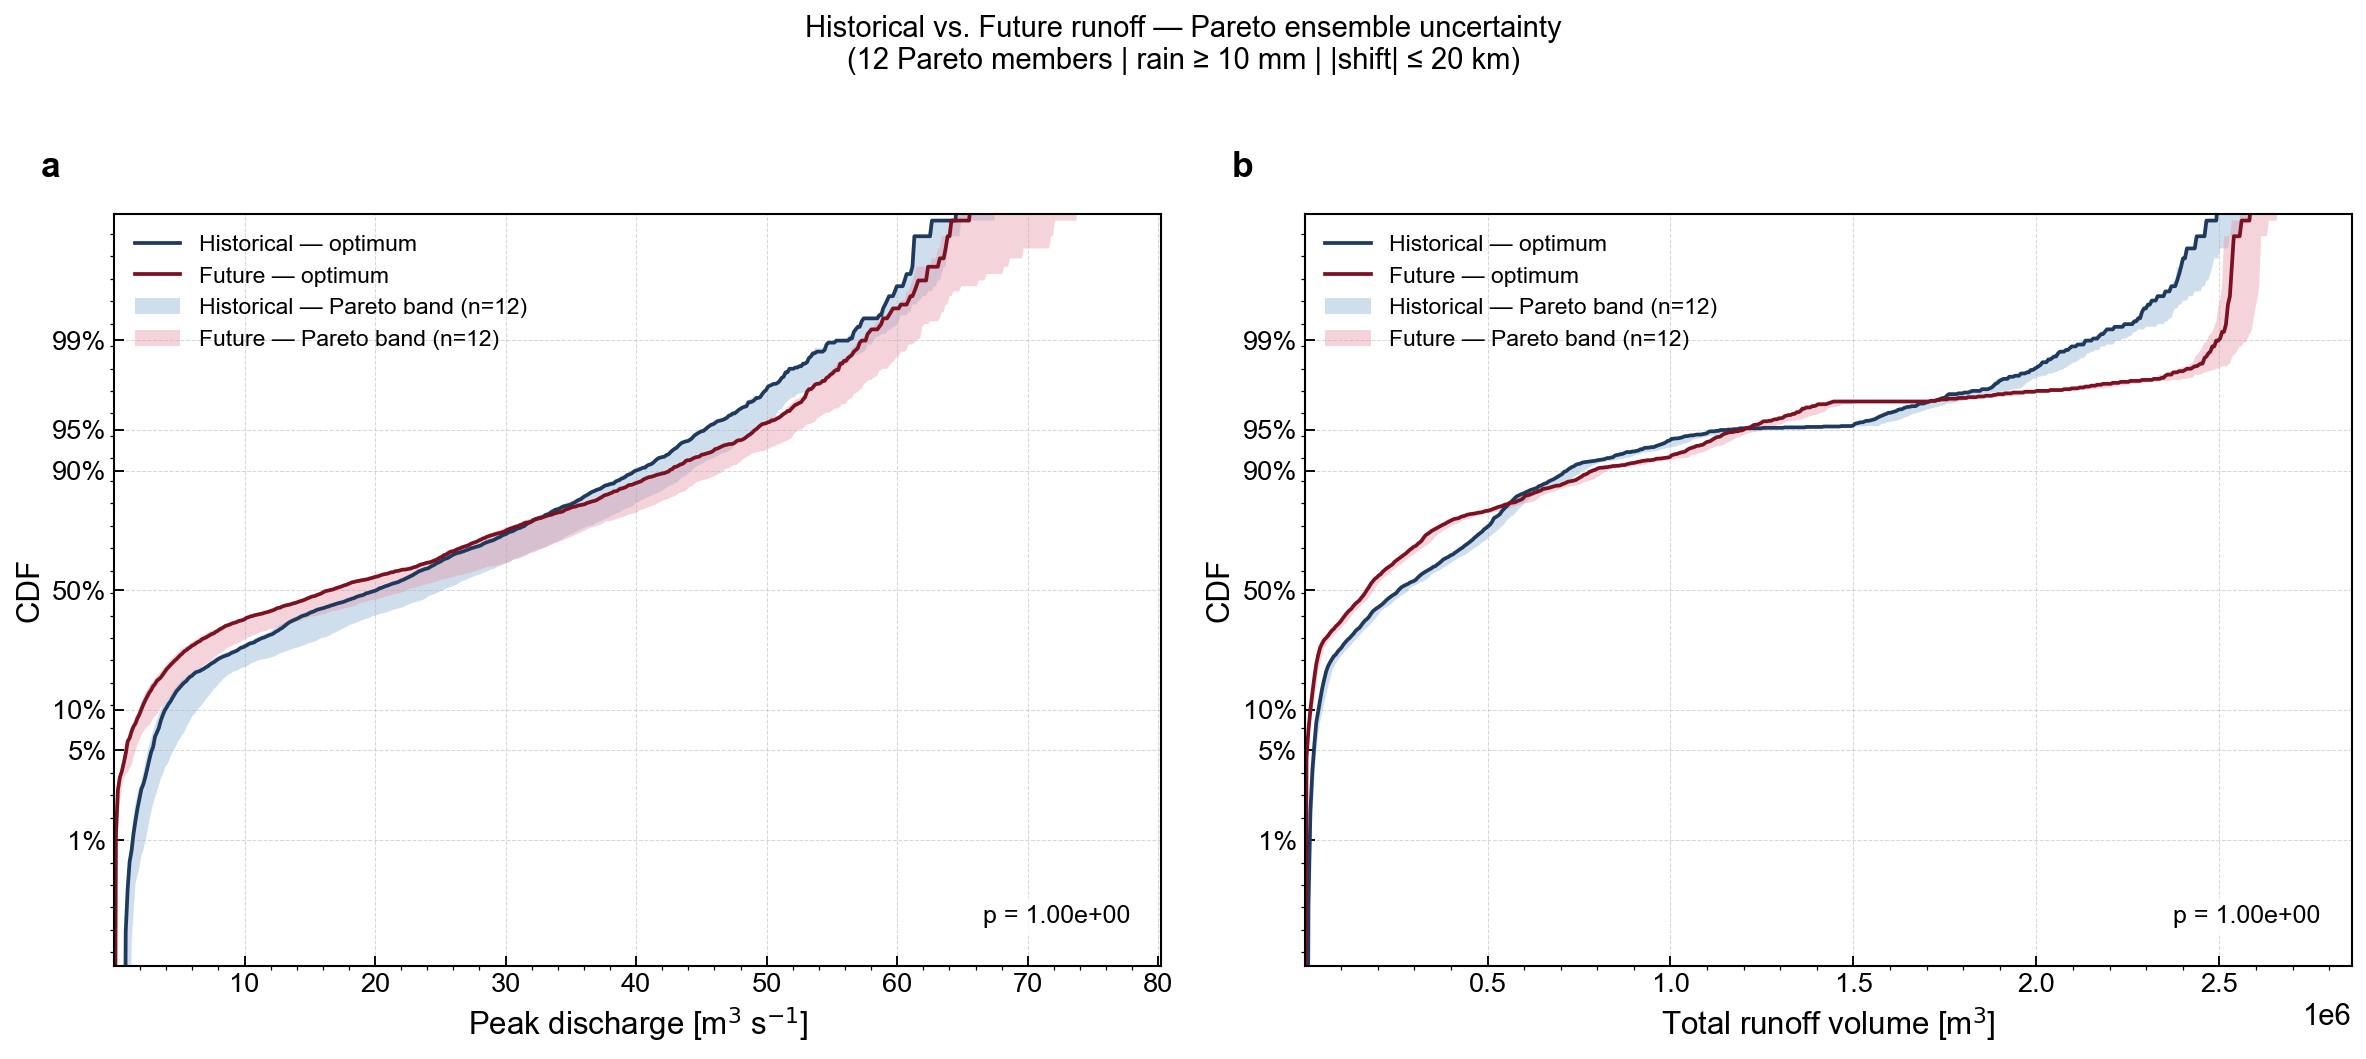

In [8]:
_HIST_COLOR = "#1E3A5F"
_HIST_FILL  = "#89AED2"
_FUT_COLOR  = "#7B1121"
_FUT_FILL   = "#E594A4"
_PCT_TICKS  = np.array([0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])


def _draw_cdf_panel(ax, x, F_h_opt, F_f_opt,
                    env_h_lo, env_h_hi, env_f_lo, env_f_hi,
                    x_label, n_mem, p_value=None, panel_label=None):
    """Single CDF panel: Pareto uncertainty bands + optimum centre lines."""
    L = _logit
    ax.fill_between(x, L(env_h_lo), L(env_h_hi),
                    color=_HIST_FILL, alpha=0.40, linewidth=0)
    ax.fill_between(x, L(env_f_lo), L(env_f_hi),
                    color=_FUT_FILL,  alpha=0.40, linewidth=0)
    ax.plot(x, L(F_h_opt), lw=1.8, color=_HIST_COLOR)
    ax.plot(x, L(F_f_opt), lw=1.8, color=_FUT_COLOR)

    ax.set_yticks(L(_PCT_TICKS))
    ax.set_yticklabels([f"{int(p*100)}%" for p in _PCT_TICKS], fontsize=13)
    ax.set_ylim(-3, 3)
    ax.set_ylabel("CDF", fontsize=15)
    ax.set_xlabel(x_label, fontsize=15)
    ax.set_xlim(left=x.min())
    ax.grid(True, ls="--", lw=0.5, alpha=0.5, zorder=0)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color("black"); sp.set_linewidth(1.0)
    ax.tick_params(axis="both", direction="in", length=5, width=0.9,
                   colors="black", labelsize=13)
    ax.minorticks_on()

    handles = [
        mlines.Line2D([], [], color=_HIST_COLOR, lw=1.8, label="Historical — optimum"),
        mlines.Line2D([], [], color=_FUT_COLOR,  lw=1.8, label="Future — optimum"),
        Patch(facecolor=_HIST_FILL, alpha=0.4, edgecolor="none",
              label=f"Historical — Pareto band (n={n_mem})"),
        Patch(facecolor=_FUT_FILL,  alpha=0.4, edgecolor="none",
              label=f"Future — Pareto band (n={n_mem})"),
    ]
    ax.legend(handles=handles, frameon=False, fontsize=11, handlelength=2.0)

    if p_value is not None:
        p_str = f"p = {p_value:.2e}" if p_value >= 1e-4 else f"p < 0.0001"
        ax.text(0.97, 0.05, p_str, transform=ax.transAxes,
                fontsize=12, ha="right", va="bottom",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"))

    if panel_label:
        ax.text(-0.07, 1.04, panel_label, transform=ax.transAxes,
                fontsize=17, fontweight="bold", ha="left", va="bottom")


n_mem = len(available)
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(16, 7), dpi=150)

_draw_cdf_panel(
    ax_a, x_peak, F_ph_opt, F_pf_opt, env_ph_lo, env_ph_hi, env_pf_lo, env_pf_hi,
    x_label=r"Peak discharge [m$^3$ s$^{-1}$]",
    n_mem=n_mem, p_value=p_peak, panel_label="a",
)
_draw_cdf_panel(
    ax_b, x_vol, F_vh_opt, F_vf_opt, env_vh_lo, env_vh_hi, env_vf_lo, env_vf_hi,
    x_label=r"Total runoff volume [m$^3$]",
    n_mem=n_mem, p_value=p_vol, panel_label="b",
)

fig.suptitle(
    f"Historical vs. Future runoff — Pareto ensemble uncertainty\n"
    f"({n_mem} Pareto members | rain \u2265 {RAIN_FILTER_MM:.0f} mm | "
    f"|shift| \u2264 {SHIFT_THRESHOLD // 1000} km)",
    fontsize=14, y=1.01,
)
fig.tight_layout()
out = FIG_DIR / "Fig_CDF_main.pdf"
fig.savefig(str(out), format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved: {out}")
plt.show()


Saved: D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\climate\figures\Fig_Pareto_Percentile_Decomposition.pdf


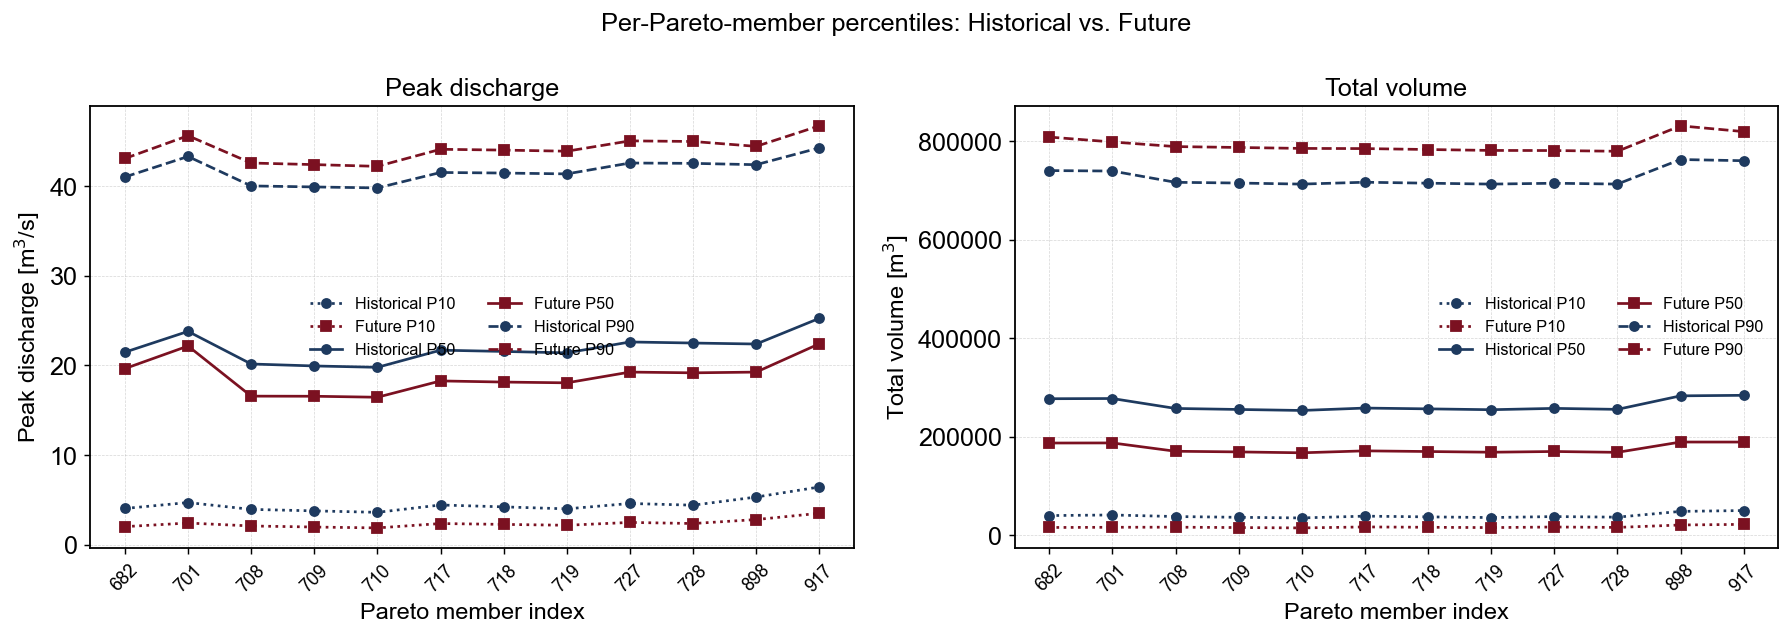

In [9]:
# Pareto decomposition: per-percentile spread across members
PERCENTILES = [10, 25, 50, 75, 90]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=130)
x_pos = np.arange(len(available))
labels = [str(i) for i in available]

for ax, (d_h, d_f, title, unit) in zip(axes, [
    (peak_h, peak_f, "Peak discharge", r"m$^3$/s"),
    (vol_h,  vol_f,  "Total volume",   r"m$^3$"),
]):
    for q, ls in [(10, ":"), (50, "-"), (90, "--")]:
        h_vals = [np.percentile(d_h[idx], q) for idx in available]
        f_vals = [np.percentile(d_f[idx], q) for idx in available]
        ax.plot(x_pos, h_vals, color=_HIST_COLOR, ls=ls, marker="o", ms=5, lw=1.5,
                label=f"Historical P{q}")
        ax.plot(x_pos, f_vals, color=_FUT_COLOR,  ls=ls, marker="s", ms=5, lw=1.5,
                label=f"Future P{q}")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=45, fontsize=10)
    ax.set_xlabel("Pareto member index", fontsize=13)
    ax.set_ylabel(f"{title} [{unit}]", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.grid(True, ls="--", lw=0.4, alpha=0.5)
    ax.legend(frameon=False, fontsize=9, ncol=2)
    for sp in ax.spines.values():
        sp.set_color("black"); sp.set_linewidth(1.0)

fig.suptitle("Per-Pareto-member percentiles: Historical vs. Future", fontsize=14)
fig.tight_layout()
out = FIG_DIR / "Fig_Pareto_Percentile_Decomposition.pdf"
fig.savefig(str(out), format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved: {out}")
plt.show()


In [10]:
# Metric summary table
print("\nMedian runoff change (Future / Historical - 1) [%]:")
print(f"  {'Member':>8}  {'Peak %':>10}  {'Volume %':>12}")
for idx in available:
    med_ph = np.median(peak_h[idx])
    med_pf = np.median(peak_f[idx])
    med_vh = np.median(vol_h[idx])
    med_vf = np.median(vol_f[idx])
    dp = (med_pf / med_ph - 1) * 100 if med_ph > 0 else np.nan
    dv = (med_vf / med_vh - 1) * 100 if med_vh > 0 else np.nan
    opt_tag = " ← optimum" if idx == opt_idx else ""
    print(f"  {idx:>8}  {dp:>+9.1f}%  {dv:>+11.1f}%{opt_tag}")



Median runoff change (Future / Historical - 1) [%]:
    Member      Peak %      Volume %
       682       -8.5%        -32.5%
       701       -6.9%        -32.5%
       708      -17.8%        -33.8% ← optimum
       709      -16.9%        -33.8%
       710      -16.9%        -33.9%
       717      -15.8%        -33.7%
       718      -15.8%        -33.8%
       719      -15.6%        -33.9%
       727      -14.8%        -34.0%
       728      -14.8%        -34.1%
       898      -14.0%        -33.1%
       917      -11.2%        -33.4%


Urban multipliers in pickles : [1.0, 2.0]
peak_by_mult mults : [1.0, 2.0]
vol_by_mult  mults : [1.0, 2.0]

X-axis labels — basin imperviousness range across 12 Pareto members:
  urban_mult=1.0  →  38.2%–42.0%  →  label: '38–42%'
  urban_mult=2.0  →  73.2%–77.1%  →  label: '73–77%'
Saved: D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\climate\figures\Fig1_4panel.pdf


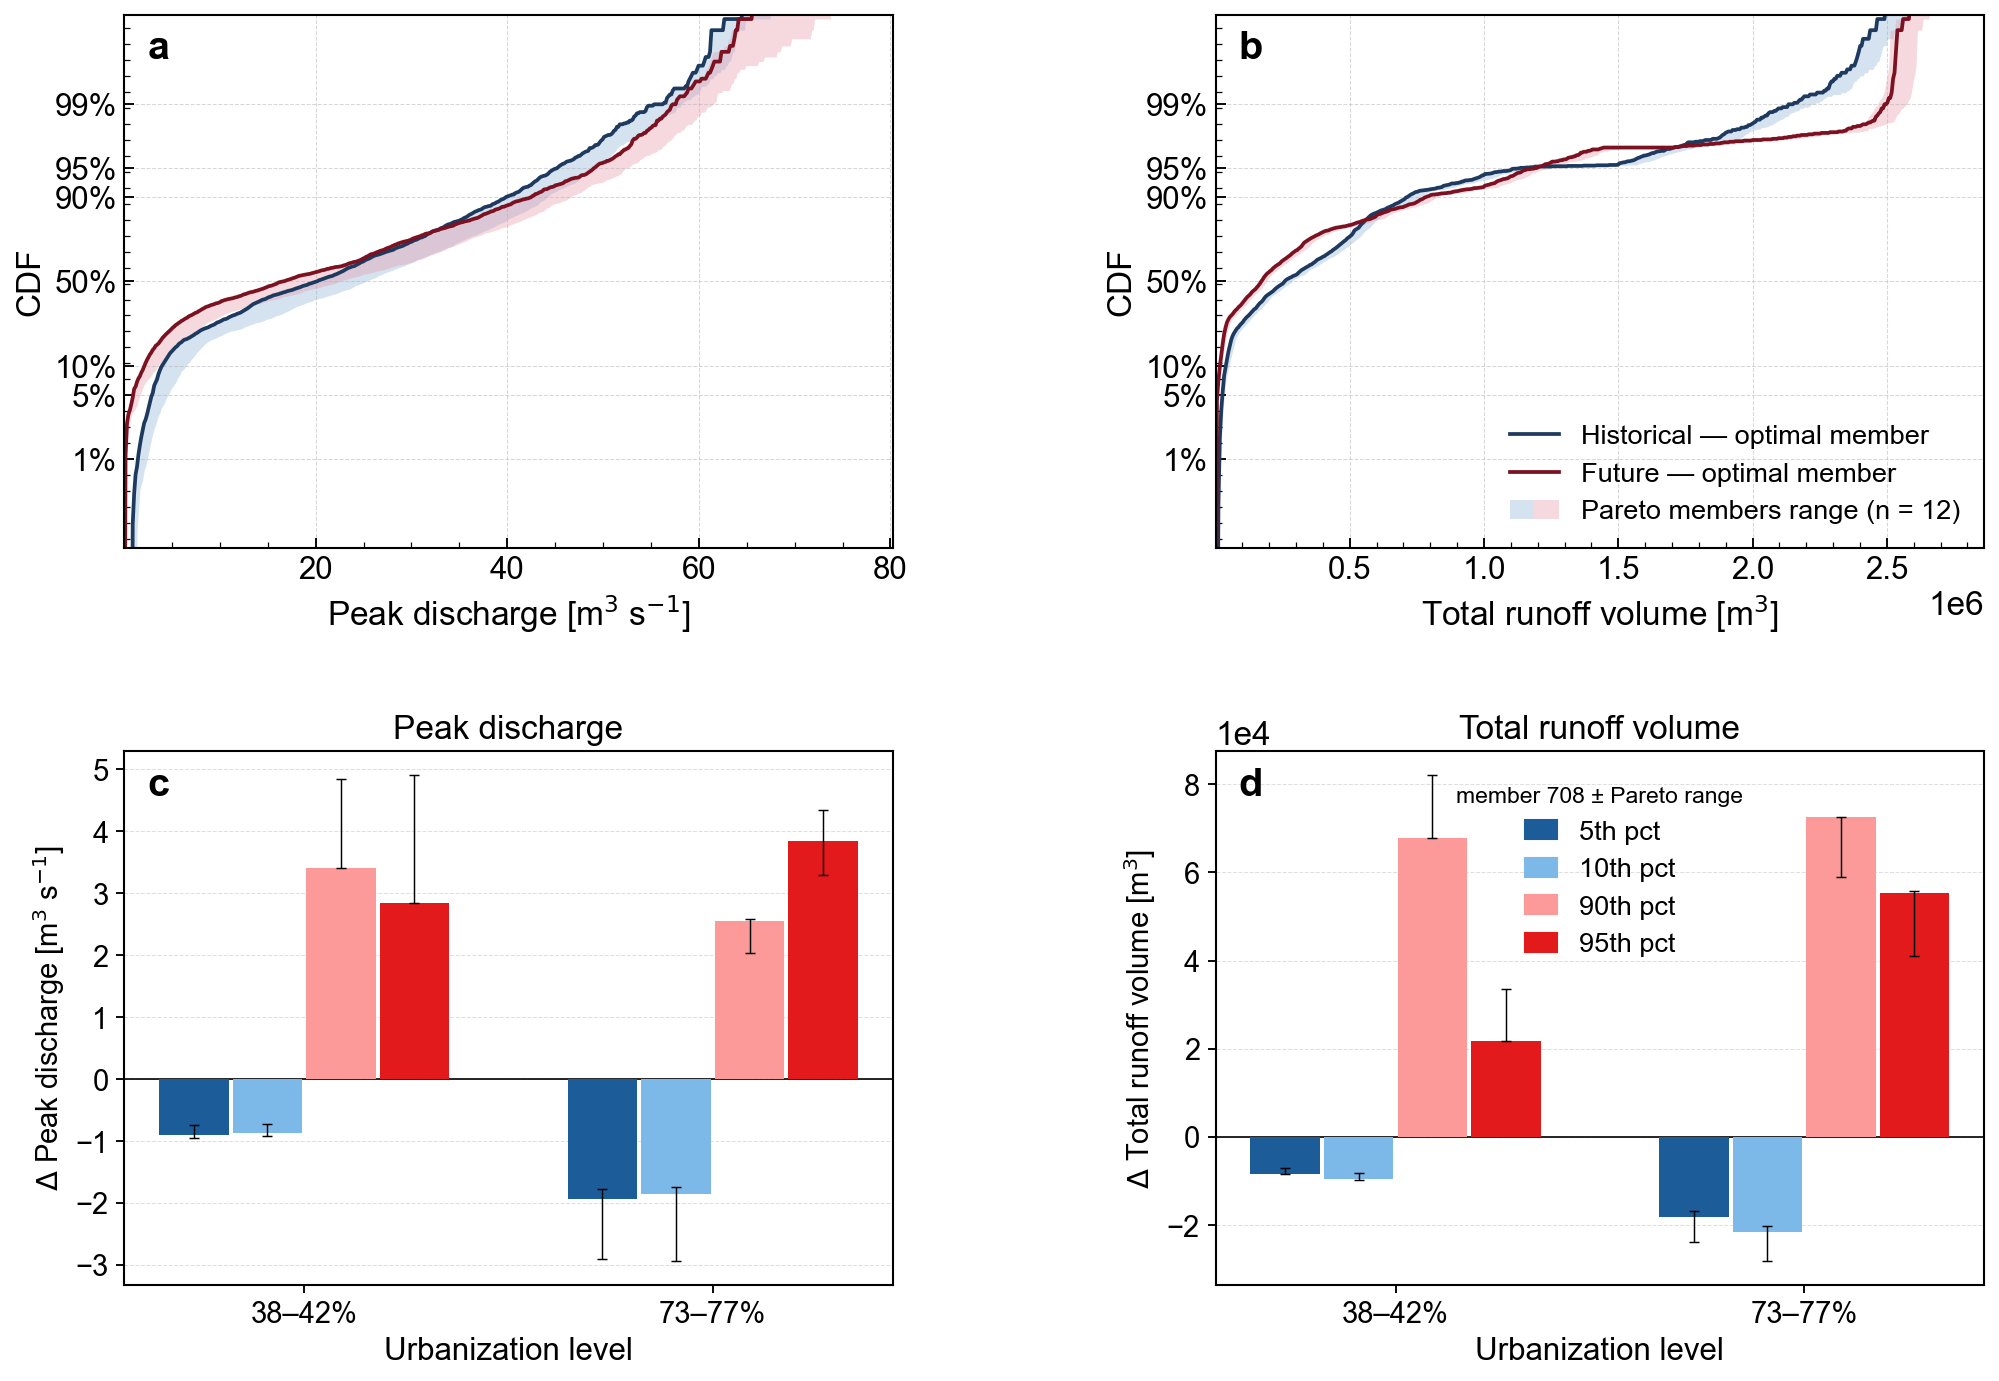

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# Publication figure — 4-panel 2×2 layout
#
#   ┌──────────────────────────┬──────────────────────────┐
#   │  (a) Peak discharge CDF  │  (b) Total volume CDF    │
#   ├──────────────────────────┼──────────────────────────┤
#   │  (c) Peak discharge Δ    │  (d) Total volume Δ      │
#   └──────────────────────────┴──────────────────────────┘
#
# Row 1 — ECDF on logit scale; Pareto min/max bands; optimal-member (708) lines.
# Row 2 — Absolute (Future − Historical) Δ bar chart; Pareto min/max error bars.
# X-axis labels: actual basin imperviousness % range across 12 Pareto members.
# Pickles loaded and filtered exactly once; 4-tuple MultiIndex key access.
# ═══════════════════════════════════════════════════════════════════════════════

from swmm_api.input_file import read_inp_file as _read_inp
from matplotlib.ticker import ScalarFormatter
from matplotlib.legend_handler import HandlerTuple

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({'font.family': 'Arial', 'font.size': 16, 'axes.linewidth': 1.0})
_BAR_COLORS  = {5: '#1c5d99', 10: '#7db9e8', 90: '#fb9a99', 95: '#e31a1c'}
_PERCENTILES = [5, 10, 90, 95]
CDF_MULT     = URBAN_SCENARIO

# Read-only data paths (same as 05_01)
_BASE_INP_PATH = Path(r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation\2012_01_13\raanana_28subcatchments.inp")
_PARETO_CSV    = Path(r"D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\pareto\final\pareto_ensemble_full.csv")


# ── Load and filter all member pickles exactly once ───────────────────────────
filtered_dfs = {}
for _idx in available:
    _raw = pd.read_pickle(str(RAW_DIR / f"pareto_{_idx}_results.pkl"))
    filtered_dfs[_idx], _ = _filter_events(_raw)

all_mults = sorted({
    col[0] for col in filtered_dfs[available[0]].columns
    if isinstance(col[0], float)
})
print(f"Urban multipliers in pickles : {all_mults}")

if CDF_MULT not in all_mults:
    CDF_MULT = all_mults[-1]
    print(f"URBAN_SCENARIO {URBAN_SCENARIO} not found — CDF panels will use {CDF_MULT}")


# ── Build per-(mult, member) data arrays ──────────────────────────────────────
def _build_mult_data(cat, metric):
    """Return {mult: {member_idx: (hist_ndarray, fut_ndarray)}} for a metric.

    4-tuple MultiIndex key access is O(1) hash lookup — equivalent to
    df.xs((mult, condition, cat, metric), axis=1) without an intermediate copy.
    """
    out = {}
    ref = filtered_dfs[available[0]]
    for mult in all_mults:
        col_h = (mult, 'historical', cat, metric)
        col_f = (mult, 'future',     cat, metric)
        if col_h not in ref.columns:
            continue
        out[mult] = {
            idx: (
                filtered_dfs[idx][col_h].to_numpy(dtype=float),
                filtered_dfs[idx][col_f].to_numpy(dtype=float),
            )
            for idx in available
        }
    return out

peak_by_mult = _build_mult_data('basin discharge', 'max_discharge')
vol_by_mult  = _build_mult_data('basin discharge', 'total_discharge')
print(f"peak_by_mult mults : {sorted(peak_by_mult)}")
print(f"vol_by_mult  mults : {sorted(vol_by_mult)}")


# ── Compute actual imperviousness % ranges for X-axis labels ──────────────────
# basin_imperv(m, u) = Σ_s [area_s × min(base_imperv_s × imp_factor_m × u, 100)]
#                     / Σ_s area_s
# Label = "{min_m:.0f}–{max_m:.0f}%" across the 12 Pareto members per mult level.
try:
    _pcsv  = pd.read_csv(str(_PARETO_CSV), header=[0, 1], index_col=0)
    _imp_s = _pcsv["Factors"]["IMP"]   # Series: member_idx → imp_factor

    _base  = _read_inp(str(_BASE_INP_PATH))
    _sc    = [(sc.imperviousness, sc.area) for sc in _base["SUBCATCHMENTS"].values()]
    _A_tot = sum(a for _, a in _sc)

    def _basin_imperv(imp_factor, urban_mult):
        """Area-weighted average imperviousness [%] across all 28 subcatchments."""
        return sum(
            min(b * imp_factor * urban_mult, 100.0) * a for b, a in _sc
        ) / _A_tot

    MULT_LABELS = {}
    print("\nX-axis labels — basin imperviousness range across 12 Pareto members:")
    for mult in all_mults:
        vals = [_basin_imperv(float(_imp_s.loc[idx]), mult) for idx in PARETO_INDICES]
        lo, hi = min(vals), max(vals)
        label  = f'{lo:.0f}–{hi:.0f}%' if (hi - lo) >= 0.5 else f'{lo:.0f}%'
        MULT_LABELS[mult] = label
        print(f"  urban_mult={mult:.1f}  →  {lo:.1f}%–{hi:.1f}%  →  label: '{label}'")

except Exception as _e:
    print(f"Warning: imperviousness labels fallback to multiplier values ({_e})")
    MULT_LABELS = {m: f'×{m:.1f}' for m in all_mults}


# ── CDF array builder ──────────────────────────────────────────────────────────
def _make_cdf_arrays(data_by_mult, mult):
    """Return (x_grid, F_h_opt, F_f_opt, band_h_lo, band_h_hi, band_f_lo, band_f_hi)."""
    h = {idx: data_by_mult[mult][idx][0] for idx in available}
    f = {idx: data_by_mult[mult][idx][1] for idx in available}
    x   = _make_x_grid(list(h.values()) + list(f.values()))
    F_h = _ecdf_on_grid(h[opt_idx], x)
    F_f = _ecdf_on_grid(f[opt_idx], x)
    sh  = np.stack([_ecdf_on_grid(h[i], x) for i in available])
    sf  = np.stack([_ecdf_on_grid(f[i], x) for i in available])
    return x, F_h, F_f, sh.min(axis=0), sh.max(axis=0), sf.min(axis=0), sf.max(axis=0)


# ── Panel A / B: ECDF with Pareto envelope ────────────────────────────────────
def _plot_cdf_panel(ax, x_grid, F_h_opt, F_f_opt,
                    band_h_lo, band_h_hi, band_f_lo, band_f_hi,
                    x_label, n_mem, panel_label='a', show_legend=True):
    """ECDF panel on logit Y-scale with Pareto parameter-uncertainty bands.

    Shaded bands  = ensemble min/max envelope across all Pareto members.
    Solid lines   = optimal member (708).
    Legend        = 3 entries: 2 lines + 1 split patch (hist + fut bands).
                    Controlled by show_legend (default True).
    Panel label   = bold, placed inside top-left corner.
    """
    L = _logit

    ax.fill_between(x_grid, L(band_h_lo), L(band_h_hi),
                    color=_HIST_FILL, alpha=0.35, linewidth=0)
    ax.fill_between(x_grid, L(band_f_lo), L(band_f_hi),
                    color=_FUT_FILL, alpha=0.35, linewidth=0)
    ax.plot(x_grid, L(F_h_opt), lw=1.8, color=_HIST_COLOR)
    ax.plot(x_grid, L(F_f_opt), lw=1.8, color=_FUT_COLOR)

    ax.set_yticks(L(_PCT_TICKS))
    ax.set_yticklabels([f'{int(p * 100)}%' for p in _PCT_TICKS], fontsize=15)
    ax.set_ylim(-3, 3)
    ax.set_ylabel('CDF', fontsize=16)
    ax.set_xlabel(x_label, fontsize=16)
    ax.set_xlim(left=x_grid.min())
    ax.grid(True, axis='both', ls='--', lw=0.5, alpha=0.5, zorder=0)

    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.0)
    ax.tick_params(axis='both', which='major',
                   direction='in', length=5, width=0.9, colors='black', labelsize=15)
    ax.tick_params(axis='both', which='minor',
                   direction='in', length=3, width=0.6, colors='black')
    ax.minorticks_on()

    if show_legend:
        _h_patch = Patch(facecolor=_HIST_FILL, alpha=0.35, edgecolor='none')
        _f_patch = Patch(facecolor=_FUT_FILL,  alpha=0.35, edgecolor='none')
        ax.legend(
            handles=[
                mlines.Line2D([], [], color=_HIST_COLOR, lw=1.8),
                mlines.Line2D([], [], color=_FUT_COLOR,  lw=1.8),
                (_h_patch, _f_patch),
            ],
            labels=[
                'Historical — optimal member',
                'Future — optimal member',
                f'Pareto members range (n = {n_mem})',
            ],
            handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
            frameon=False, fontsize=13, handlelength=1.8,
            loc='lower right',
        )

    # Panel label — bold, inside top-left corner
    ax.text(0.03, 0.97, panel_label, transform=ax.transAxes,
            fontsize=19, fontweight='bold', ha='left', va='top')


# ── Panels C / D: absolute delta bars ─────────────────────────────────────────
def _plot_delta_panel(ax, data_by_mult, percentiles=None,
                      y_label='', title=None, panel_label=None,
                      show_legend=False):
    """Absolute (Future − Historical) Δ bar chart with Pareto uncertainty.

    Bar geometry  : bar_w=0.17, offsets = linspace(-0.27, 0.27, 4) — verbatim
                    from legacy 02a.
    Error bars    : Pareto ensemble min/max whiskers — no bootstrap.
        delta_i(q) = P(future_i, q) − P(hist_i, q)
        Bar height = delta_{708}(q)
        Whisker lo = delta_{708}(q) − min_i(delta_i)
        Whisker hi = max_i(delta_i)  − delta_{708}(q)
    X-axis labels : MULT_LABELS (actual imperviousness % ranges).
    Panel label   : bold, inside top-left corner.
    """
    if percentiles is None:
        percentiles = _PERCENTILES
    mults   = sorted(data_by_mult.keys())
    x_ticks = np.arange(len(mults))
    bar_w   = 0.17
    offsets = np.linspace(-0.27, 0.27, len(percentiles))

    for i, q in enumerate(percentiles):
        vals, lo_err, hi_err = [], [], []
        for mult in mults:
            md = data_by_mult[mult]
            d = np.array([
                np.percentile(md[j][1], q) - np.percentile(md[j][0], q)
                for j in available
            ])
            opt_d = float(np.percentile(md[opt_idx][1], q) -
                          np.percentile(md[opt_idx][0], q))
            vals.append(opt_d)
            lo_err.append(float(opt_d - d.min()))
            hi_err.append(float(d.max() - opt_d))

        ax.bar(x_ticks + offsets[i], vals, width=bar_w,
               color=_BAR_COLORS[q], edgecolor='none', zorder=3)
        ax.errorbar(x_ticks + offsets[i], vals, yerr=[lo_err, hi_err],
                    fmt='none', ecolor='black', elinewidth=0.7,
                    capsize=2.5, capthick=0.7, zorder=4)

    ax.axhline(0, color='black', lw=0.8, zorder=2)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(
        [MULT_LABELS.get(m, f'×{m:.1f}') for m in mults], fontsize=15,
    )
    ax.set_xlabel('Urbanization level', fontsize=15)
    ax.set_ylabel(y_label, fontsize=14)
    if title:
        ax.set_title(title, fontsize=16, pad=6)

    ax.grid(axis='y', ls='--', lw=0.5, alpha=0.4, zorder=0)
    ax.tick_params(axis='both', labelsize=14, width=0.9, length=4, direction='out')

    fmt = ScalarFormatter(useMathText=False)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(fmt)

    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(1.0)

    if show_legend:
        ax.legend(
            handles=[Patch(color=_BAR_COLORS[q], label=f'{q}th pct')
                     for q in percentiles],
            frameon=False, fontsize=13,
            title=f'member {opt_idx} ± Pareto range', title_fontsize=11,
            loc='best', borderpad=0.8, handlelength=1.2,
        )

    if panel_label:
        ax.text(0.03, 0.97, panel_label, transform=ax.transAxes,
                fontsize=19, fontweight='bold', ha='left', va='top')


# ═══════════════════════════════════════════════════════════════════════════════
# Figure — 4-panel 2×2
# ═══════════════════════════════════════════════════════════════════════════════
_pk = _make_cdf_arrays(peak_by_mult, CDF_MULT)
_vl = _make_cdf_arrays(vol_by_mult,  CDF_MULT)

fig = plt.figure(figsize=(16, 11), dpi=150)
axd = fig.subplot_mosaic(
    [['a', 'b'], ['c', 'd']],
    gridspec_kw={'hspace': 0.38, 'wspace': 0.42},
)

# ── Row 1: CDF panels ──────────────────────────────────────────────────────────
_plot_cdf_panel(
    axd['a'],
    x_grid    = _pk[0],
    F_h_opt   = _pk[1],   F_f_opt   = _pk[2],
    band_h_lo = _pk[3],   band_h_hi = _pk[4],
    band_f_lo = _pk[5],   band_f_hi = _pk[6],
    x_label   = r'Peak discharge [m$^3$ s$^{-1}$]',
    n_mem     = len(available),
    panel_label  = 'a',
    show_legend  = False,   # ← toggle legend on/off per panel
)

_plot_cdf_panel(
    axd['b'],
    x_grid    = _vl[0],
    F_h_opt   = _vl[1],   F_f_opt   = _vl[2],
    band_h_lo = _vl[3],   band_h_hi = _vl[4],
    band_f_lo = _vl[5],   band_f_hi = _vl[6],
    x_label   = r'Total runoff volume [m$^3$]',
    n_mem     = len(available),
    panel_label  = 'b',
    show_legend  = True,   # ← toggle legend on/off per panel
)

# ── Row 2: Absolute delta panels ───────────────────────────────────────────────
_plot_delta_panel(
    axd['c'],
    data_by_mult = peak_by_mult,
    y_label      = r'$\Delta$ Peak discharge [m$^3$ s$^{-1}$]',
    title        = 'Peak discharge',
    panel_label  = 'c',
    show_legend  = False,
)

_plot_delta_panel(
    axd['d'],
    data_by_mult = vol_by_mult,
    y_label      = r'$\Delta$ Total runoff volume [m$^3$]',
    title        = 'Total runoff volume',
    panel_label  = 'd',
    show_legend  = True,
)

out = FIG_DIR / 'Fig1_4panel.pdf'
fig.savefig(str(out), format='pdf', bbox_inches='tight', dpi=300)
print(f'Saved: {out}')
plt.show()

Saved: D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\climate\figures\Fig2_volume_focus.pdf


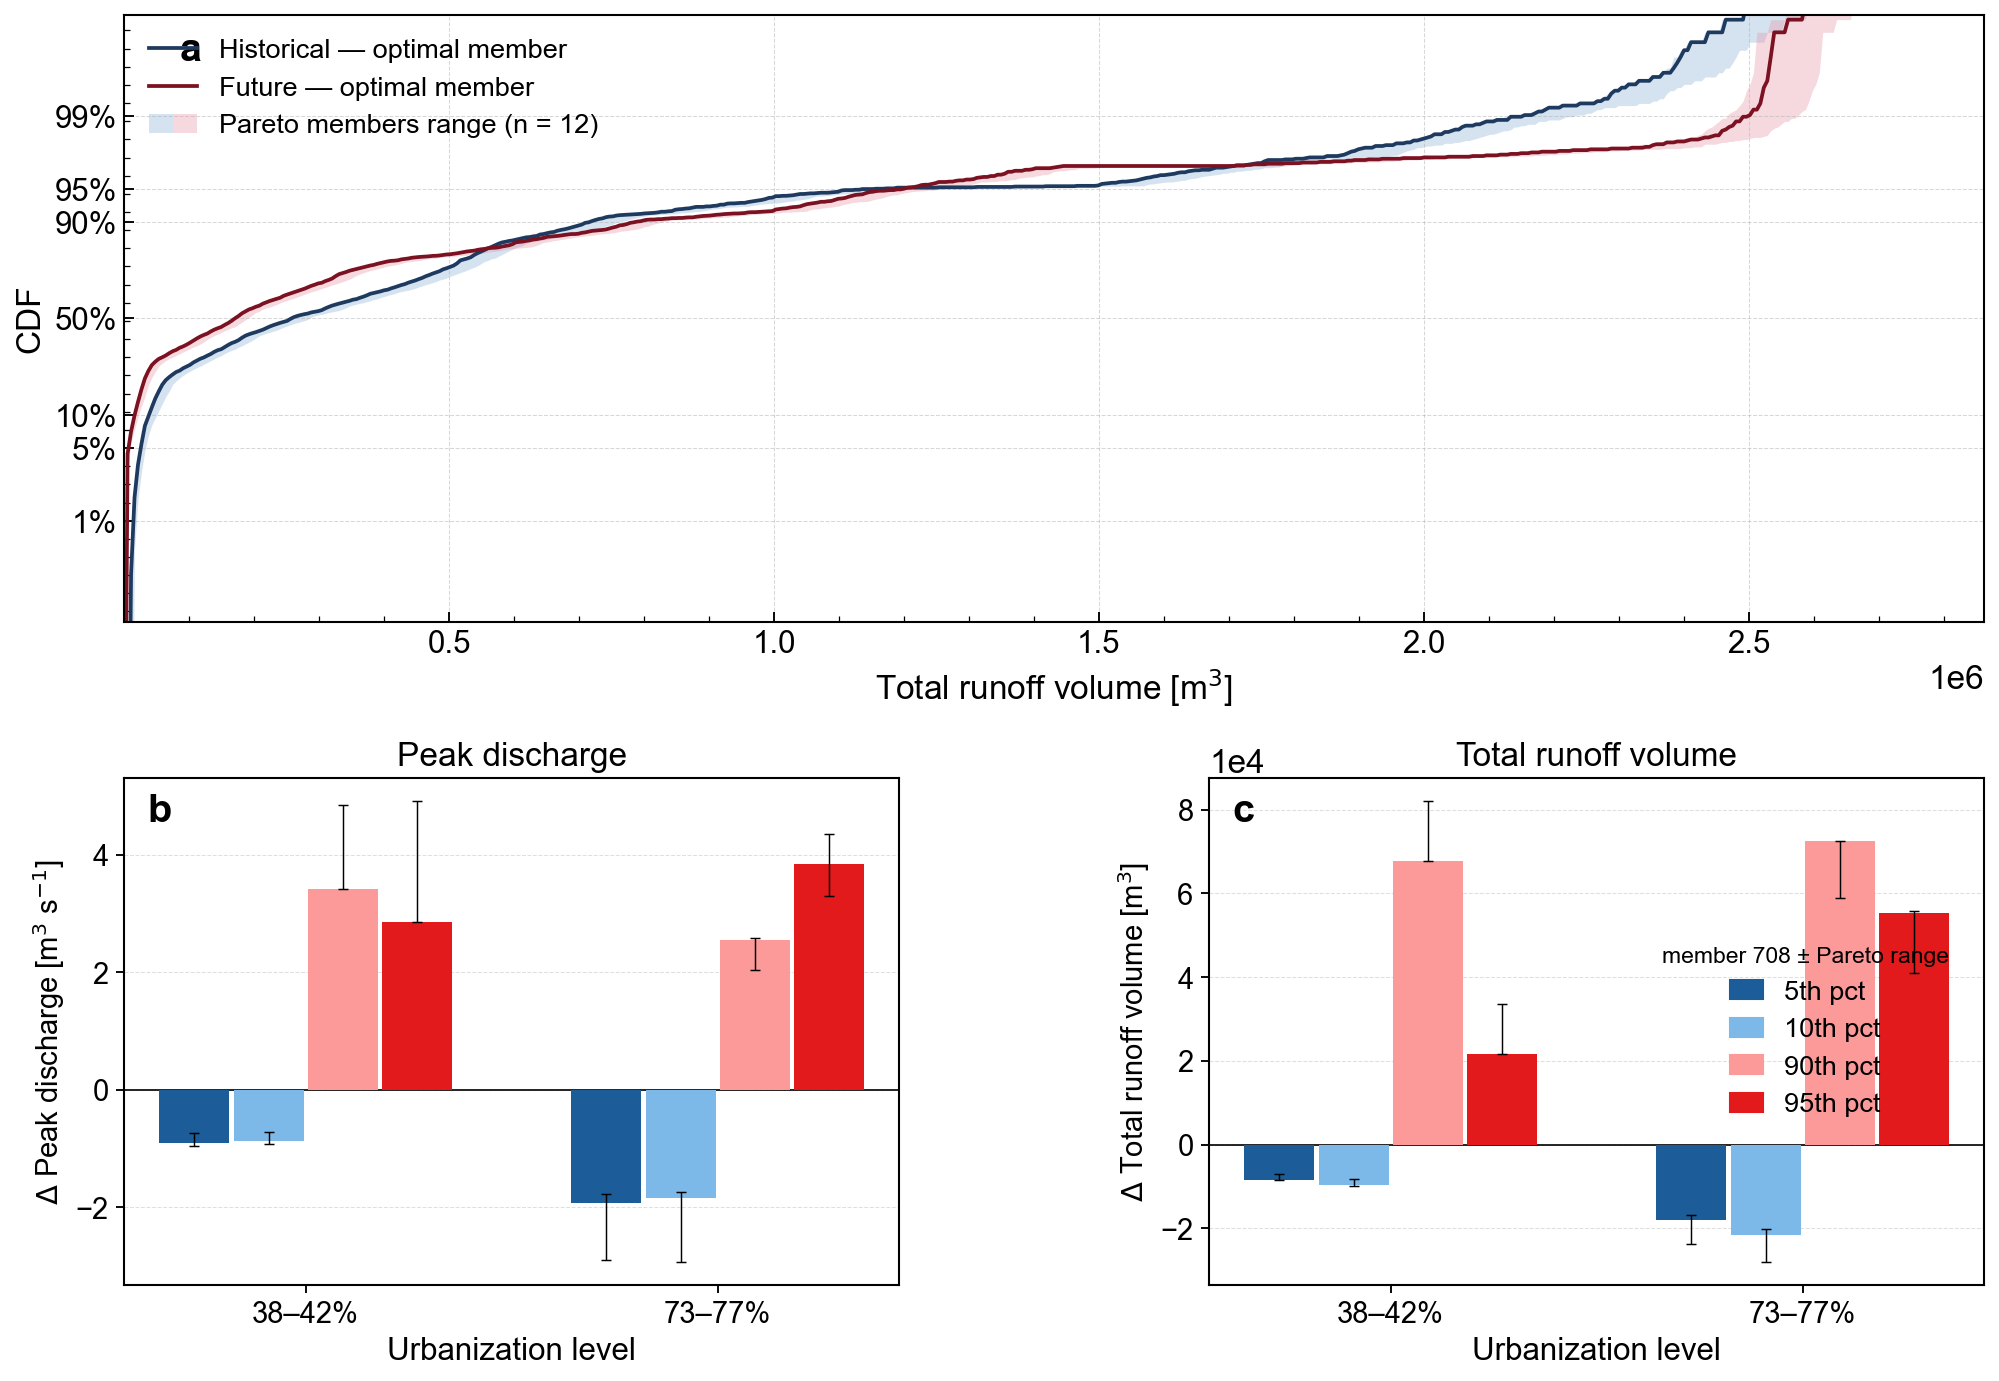

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# Figure 2 — Volume-focused companion (optional / supplementary)
#
# Panel A: total runoff volume ECDF; Panels B/C: peak & volume absolute Δ bars.
# All helpers and data dicts (_plot_cdf_panel, _plot_delta_panel, peak_by_mult,
# vol_by_mult, MULT_LABELS, CDF_MULT) are defined in the preceding cell dc72b25e.
# ═══════════════════════════════════════════════════════════════════════════════
_vl2 = _make_cdf_arrays(vol_by_mult, CDF_MULT)

fig2 = plt.figure(figsize=(16, 11), dpi=150)
axd2 = fig2.subplot_mosaic(
    [['a', 'a'], ['b', 'c']],
    gridspec_kw={'hspace': 0.28, 'wspace': 0.40, 'height_ratios': [1.2, 1.0]},
)

_plot_cdf_panel(
    axd2['a'],
    x_grid    = _vl2[0],
    F_h_opt   = _vl2[1],   F_f_opt   = _vl2[2],
    band_h_lo = _vl2[3],   band_h_hi = _vl2[4],
    band_f_lo = _vl2[5],   band_f_hi = _vl2[6],
    x_label   = r'Total runoff volume [m$^3$]',
    n_mem     = len(available),
    panel_label = 'a',
)

_plot_delta_panel(
    axd2['b'],
    data_by_mult = peak_by_mult,
    y_label      = r'$\Delta$ Peak discharge [m$^3$ s$^{-1}$]',
    title        = 'Peak discharge',
    panel_label  = 'b',
    show_legend  = False,
)

_plot_delta_panel(
    axd2['c'],
    data_by_mult = vol_by_mult,
    y_label      = r'$\Delta$ Total runoff volume [m$^3$]',
    title        = 'Total runoff volume',
    panel_label  = 'c',
    show_legend  = True,
)

out2 = FIG_DIR / 'Fig2_volume_focus.pdf'
fig2.savefig(str(out2), format='pdf', bbox_inches='tight', dpi=300)
print(f'Saved: {out2}')
plt.show()